# In this file I will use QIIME2 to calculate the alpha diversity, alpha correlation and beta diversity using the feature table listed in QIITA and combined_df that I created earlier
## After making these calculations, I will use matplotlib to create 3 graphs showing the alpha correlation for each vitamin D metabolite (1,25(OH)D3 (pg/ml), 24,25(OH)D3 (ng/ml), 25(OH)D3 (ng/ml))
Before you start please make sure you have the following
- QIIME2, a microbiome analysis package
- a combined dataframe including both the metadata values (information about the samples) and the vitamin D OH4Aug17_df dataset with the vitamin D metabolites
- downloaded the feature table from the study using QIITA (file name is feature_table.qza): https://qiita.ucsd.edu/study/description/11274#

## Calculating alpha diversity: this will show an alpha diversity metric for all samples within a feature table
I used two metrics to calculate alpha diversity: Chao1 and Shannon

### Step 1. calculate alpha diversity metrics using Chao1
Here I followed the basic format of calculating Chao1 by using the feature table and creating a table with the Chao1 alpha diversity metrics

In [ ]:
!qiime diversity alpha \
    !--i-table feature_table.qza \
    !--p-metric chao1 \
    !--o-alpha-diversity chao1_vector.qza

### Step 2. calculate alpha diversity metrics using Shannon 

In [ ]:
!qiime diversity alpha \
    !--i-table feature_table.qza \
    !--p-metric shannon \
    !--o-alpha-diversity shannon_vector.qza

### Step 3. Calculate alpha correlations: this will show if the metadata columns are correlated with alpha diversity 

In [ ]:
#Step 3a. Using Chao1
!qiime diversity alpha-correlation \
    !--i-alpha-diversity chao1_vector.qza \
    !--m-metadata-file /Users/verisha/Downloads/BBIO_383/Project_2/combined_df.tsv \
    !--o-visualization try_visualization.qzv \
    !--p-intersect-ids #only keep IDs that match with alpha diversity metrics and metadata file

In [ ]:
#Step 3b. Using Shannon 
!qiime diversity alpha-correlation \
    !--i-alpha-diversity shannon_vector.qza \
    !--m-metadata-file /Users/verisha/Downloads/BBIO_383/Project_2/combined_df.tsv \
    !--o-visualization alphadiv_shannon_visualization.qzv \
    !--p-intersect-ids

### Step 4: Create alpha rarefaction curves 
This addresses if our alpha diversity looks more diverse because of some samples being sequenced more often

In [ ]:
!qiime diversity alpha-rarefaction \
    !--i-table feature_table.qza \
    !--p-max-depth 500 \
    !--p-metrics 'observed_features' \
    !--o-visualization alphadiv_rarefaction.qzv

## Step 5. Calculating beta diversity

### Step 5a. Using the Jaccard Index to create a beta-diversity metric for all sample pairs with a feature table as an output

In [ ]:
!qiime diversity beta \
    !--i-table feature_table.qza \
    !--p-metric jaccard \
    !--o-distance-matrix jaccard_results.qza

### Step 5b. Using Bray-Curtis 

In [ ]:
!qiime diversity beta \
    !--i-table feature_table.qza \
    !--p-metric braycurtis \
    !--o-distance-matrix braycurtis_results.qza

### Step 6. Create a Principle Coordinate of Analysis Plot (PCOA) to show our beta diversity metrics in a visualization

### Step 6a. Creating a Jaccard Index PCOA

In [ ]:
!qiime diversity pcoa \
    !--i-distance-matrix jaccard_results.qza \
    !--o-pcoa pcoa_jaccard.qza

In [ ]:
!qiime emperor plot \
    !--i-pcoa pcoa_jaccard.qza \
    !--m-metadata-file combined_df.tsv \
    !--p-ignore-missing-samples \
    !--o-visualization visualization_pcoa_jaccard.qzv

### Step 6b. Creating a Bray-Curtis Dissimilarity PCOA 

In [ ]:
!qiime diversity pcoa \
    !--i-distance-matrix braycurtis_results.qza \
    !--o-pcoa pcoa_braycurtis.qza

In [ ]:
!qiime emperor plot \
    !--i-pcoa pcoa_braycurtis.qza \
    !--m-metadata-file combined_df.tsv \
    !--p-ignore-missing-samples \
    !--o-visualization visualization_pcoa_braycurtis.qzv

To view your QZA tables and QZV visualizations, use https://view.qiime2.org/

### Step 7. Create visualizations of alpha diversity in python
Although the graphs in QIIME2 and Python show the same exact data, graphs in Python allow for more flexibility in adding labels and legends, changing axes and adding a background. I have created the graphs with additional features below. 

1. upload data
2. clean data: remove unecessary rows
3. create subset of data w/ 2 vars need: ID & vitamin D metabolite
4. add x & y labels
5. add legend 

In [4]:
from os import listdir
listdir()

['MrOS_Vitamin D_Stat',
 'combined_df.tsv',
 'alphadiv_shannon_visualization.qzv',
 'alphadiv_chao1.tsv',
 'shannon_vector.qza',
 'beta_significance.qzv',
 'feature_table.qza',
 '.DS_Store',
 'metadata.txt',
 'feature_table_export',
 'all.seqs.fa',
 'OLD_alpha_diversity_df.tsv',
 'braycurtis_filtered.qza',
 'OH4AUG17_CONTENTS copy.PDF',
 'data_feature-table.biom',
 'Supplementary_Code_Verisha_Bhatti_Procedure_File.ipynb',
 'OH4Aug17.csv',
 'combined_df',
 'knightlab-analyses-vitamin-d-66ab000',
 'feature_table.tsv',
 '.ERR2518451.fastq.swp',
 'observed_features_vector.qza',
 'filtered_df.tsv',
 'vitD_seq_data.tsv',
 'alphadiv_shannon.tsv',
 'alphadiv_chao1_visualization.qzv',
 'NEW combined_df.ipynb',
 'visualization_pcoa_jaccard.qzv',
 'Viz',
 'filereport_read_run_ERP107984.tsv',
 'MrOSAUG24',
 'Supplementary_Code_Verisha_Bhatti_Create_Combined_Dataframe.ipynb',
 'chao1_OHVD3.svg',
 'braycurtis_results.qza',
 'metadata.csv',
 '.ipynb_checkpoints',
 'Alpha_Correlation_OHV24D3.tsv',
 'c

In [21]:
import pandas as pd 
chao1_df = pd.read_csv('alphadiv_chao1.tsv',sep = "\t", index_col = False)

In [22]:
type(chao1_df)
chao1_df

#check data types for all columns
chao1_df.dtypes

id                object
elevation         object
host_taxid        object
latitude          object
longitude         object
qiita_study_id    object
taxon_id          object
Unnamed: 0        object
OHV1D3            object
OHV24D3           object
OHVD3             object
OHVD2             object
OHV1D2            object
OHV1D2CT          object
OHVD2CT           object
OHVDTOT           object
OHV1DTOT          object
OHVD2I            object
OHVD3I            object
OHV1D2I           object
OHV1D3I           object
OHV24D3I          object
OHMONTH           object
OHSEAS            object
chao1             object
dtype: object

#### Step 7b. Data cleaning and creating subset of data 

In [29]:
#create subset of data with only vitamin D metabolites (vitD) and chao1 indices
#convert vitamin D metabolites and chao1 to numerical data
chao1_vitD_df = chao1_df[["OHV1D3", "OHV24D3", "OHVD3", "chao1"]].apply(pd.to_numeric, errors='coerce')

In [31]:
#remove missing values
chao1_vitD_df = chao1_vitD_df.dropna() 

In [33]:
#check subset data
chao1_vitD_df 

,OHV1D3,OHV24D3,OHVD3,chao1
1,39.3,1.77,25.8,505.000000
2,61.9,3.91,39.2,255.632653
3,52.1,1.49,23.1,356.081395
4,43.1,2.14,27.3,305.166667
5,50.2,3.62,33.0,298.000000
...,...,...,...,...
563,41.8,1.58,20.8,275.517857
564,55.1,3.91,36.2,576.000000
565,42.6,3.16,37.6,150.250000
566,81.3,3.39,32.0,381.692308


#### Step 7c. Create graphs showing Chao1 species richness and vitamin D metabolite levels using matplotlib

In [39]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import scatter,xlabel,ylabel 

<Figure size 800x600 with 0 Axes>

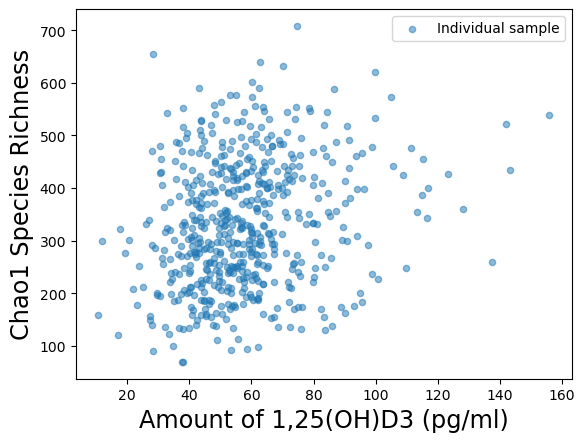

In [48]:
#OHV1D3
plt.figure(figsize=(8, 6))
chao1_vitD_df.plot.scatter(
    x="OHV1D3", y="chao1", alpha = 0.5)
plt.xlabel("Amount of 1,25(OH)D3 (pg/ml)", size = "xx-large")
plt.ylabel("Chao1 Species Richness", size = "xx-large")
plt.legend(['Individual sample'], loc = "upper right") 
plt.savefig("chao1_OHV1D3_viz.png", dpi = 500, bbox_inches="tight")

<Figure size 800x600 with 0 Axes>

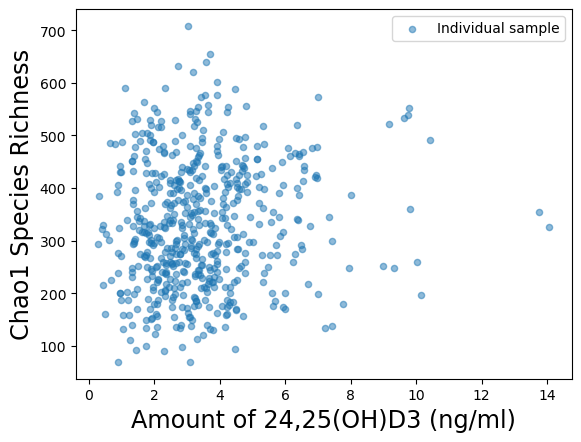

In [49]:
#OHV24D3
plt.figure(figsize=(8, 6))
chao1_vitD_df.plot.scatter(
    x="OHV24D3", y="chao1", alpha = 0.5)
plt.xlabel("Amount of 24,25(OH)D3 (ng/ml)", size = "xx-large")
plt.ylabel("Chao1 Species Richness", size = "xx-large")
plt.legend(['Individual sample'], loc = "upper right") 
plt.savefig("chao1_OHV24D3_viz.png", dpi = 500, bbox_inches="tight")

<Figure size 800x600 with 0 Axes>

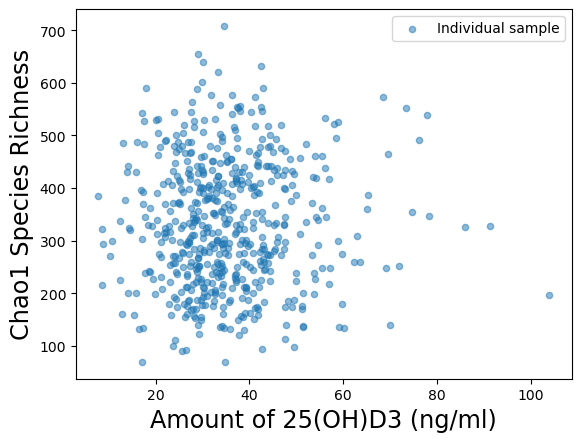

In [50]:
#OHVD3
plt.figure(figsize=(8, 6))
chao1_vitD_df.plot.scatter(
    x="OHVD3", y="chao1", alpha = 0.5)
plt.xlabel("Amount of 25(OH)D3 (ng/ml)", size = "xx-large")
plt.ylabel("Chao1 Species Richness", size = "xx-large")
plt.legend(['Individual sample'], loc = "upper right") 
plt.savefig("chao1_OHVD3_viz.png", dpi = 500, bbox_inches="tight")

#### Step 7c. Repeat thsi process using Shannon Index instead 

In [61]:
import pandas as pd 
shannon_df = pd.read_csv('alphadiv_shannon.tsv',sep = "\t", index_col = False)

In [62]:
shannon_df.dtypes

id                 object
elevation          object
host_taxid         object
latitude           object
longitude          object
qiita_study_id     object
taxon_id           object
Unnamed: 0         object
OHV1D3             object
OHV24D3            object
OHVD3              object
OHVD2              object
OHV1D2             object
OHV1D2CT           object
OHVD2CT            object
OHVDTOT            object
OHV1DTOT           object
OHVD2I             object
OHVD3I             object
OHV1D2I            object
OHV1D3I            object
OHV24D3I           object
OHMONTH            object
OHSEAS             object
shannon_entropy    object
dtype: object

In [63]:
shannon_vitD_df = shannon_df[["OHV1D3", "OHV24D3", "OHVD3", "shannon_entropy"]].apply(pd.to_numeric, errors='coerce')

In [64]:
shannon_vitD_df  = shannon_vitD_df .dropna() 

In [65]:
shannon_vitD_df 

,OHV1D3,OHV24D3,OHVD3,shannon_entropy
1,39.3,1.77,25.8,5.674917
2,61.9,3.91,39.2,3.687098
3,52.1,1.49,23.1,4.382908
4,43.1,2.14,27.3,4.919620
5,50.2,3.62,33.0,5.371553
...,...,...,...,...
563,41.8,1.58,20.8,4.776409
564,55.1,3.91,36.2,5.405843
565,42.6,3.16,37.6,3.808872
566,81.3,3.39,32.0,4.686425


<Figure size 800x600 with 0 Axes>

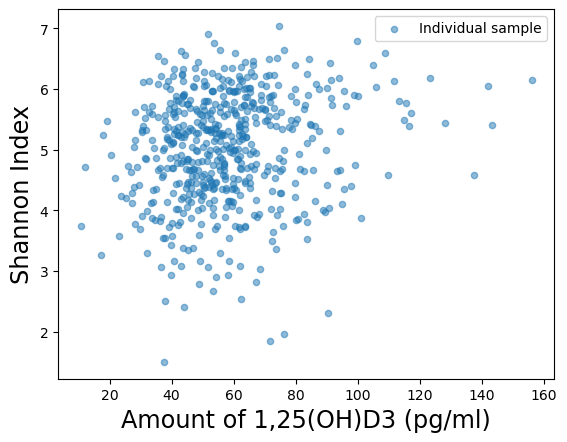

In [69]:
#OHV1D3
plt.figure(figsize=(8, 6))
shannon_vitD_df .plot.scatter(
    x="OHV1D3", y="shannon_entropy", alpha = 0.5)
plt.xlabel("Amount of 1,25(OH)D3 (pg/ml)", size = "xx-large")
plt.ylabel("Shannon Index", size = "xx-large")
plt.legend(['Individual sample'], loc = "upper right") 
plt.savefig("shannon_OHV1D3_viz.png", dpi = 500, bbox_inches="tight")


<Figure size 800x600 with 0 Axes>

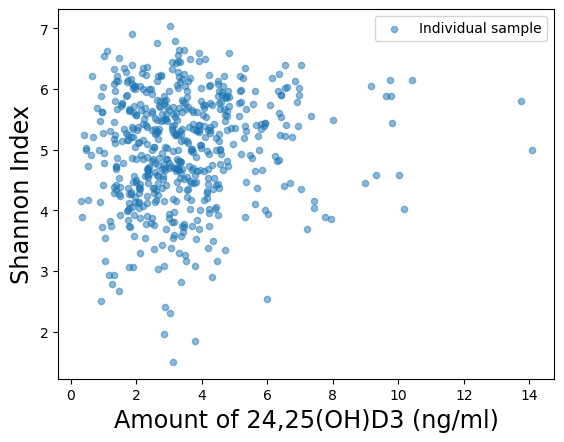

In [67]:
#OHV24D3
plt.figure(figsize=(8, 6))
shannon_vitD_df .plot.scatter(
    x="OHV24D3", y="shannon_entropy", alpha = 0.5)
plt.xlabel("Amount of 24,25(OH)D3 (ng/ml)", size = "xx-large")
plt.ylabel("Shannon Index", size = "xx-large")
plt.legend(['Individual sample'], loc = "upper right") 
plt.savefig("shannon_OHV24D3_viz.png", dpi = 500, bbox_inches="tight")


<Figure size 800x600 with 0 Axes>

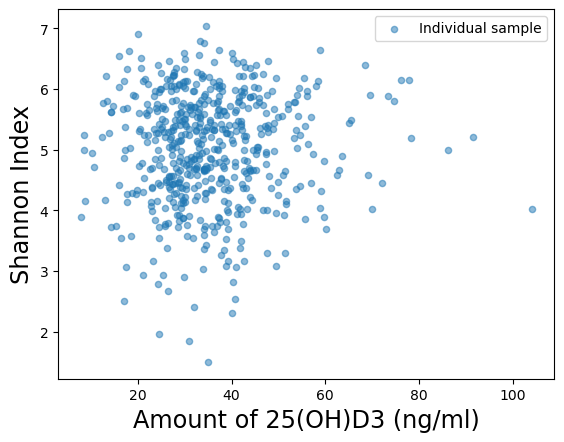

In [68]:
#OHVD3
plt.figure(figsize=(8, 6))
shannon_vitD_df .plot.scatter(
    x="OHVD3", y="shannon_entropy", alpha = 0.5)
plt.xlabel("Amount of 25(OH)D3 (ng/ml)", size = "xx-large")
plt.ylabel("Shannon Index", size = "xx-large")
plt.legend(['Individual sample'], loc = "upper right") 
plt.savefig("shannon_OHVD3_viz.png", dpi = 500, bbox_inches="tight")